In [1]:
%load_ext watermark


In [2]:
import os

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-20T20:14:53.600862+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

scipy  : 1.14.1
pandas : 2.2.3
teeplot: 1.4.2
seaborn: 0.13.2
polars : 1.29.0
numpy  : 2.1.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-freqscreen-summary"
teeplot_subdir


'2025-05-19-freqscreen-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "dummy": "https://osf.io/cjqx2/download",
    "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    "vanilla": "https://osf.io/r8skg/download",
    "vanilla-big": "https://osf.io/j4795/download",
    "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    pl.scan_parquet(
        url,
        low_memory=True,
        retries=5,
    ).sink_parquet(tmp_path)
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        phylo_df = (
            df.filter(
                (pl.col("trt_name") == trt_name)
                & (pl.col("trt_n_downsample") == trt_n_downsample)
                & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
                & (pl.col("replicate_uuid") == replicate_uuid)
            )
            .collect(engine="streaming")
            .to_pandas()
        )

        num_muts = phylo_df["defmut_mask_sum"].astype(bool).sum()
        num_focal_muts = phylo_df["is_focal_defmut"].sum()
        num_bg_sites = phylo_df["cfg_maxseqlen"].unique().item()

        expected_num_muts = (
            phylo_df["defmut_mask_sum"].sum() - num_focal_muts
        ) / num_bg_sites

        lambda_poisson = expected_num_muts
        p_poisson = scipy_stats.poisson.sf(num_focal_muts, lambda_poisson)

        results.append(
            {
                "source_name": source_name,
                "trt_name": trt_name,
                "trt_n_downsample": trt_n_downsample,
                "trt_hsurf_bits": trt_hsurf_bits,
                "replicate_uuid": replicate_uuid,
                "num_muts": num_muts,
                "num_focal_muts": num_focal_muts,
                "num_bg_sites": num_bg_sites,
                "expected_num_muts": expected_num_muts,
                "p_poisson": p_poisson,
                "lambda_poisson": lambda_poisson,
            }
        )


done!


100%|██████████| 70/70 [00:28<00:00,  2.42it/s]


done!


100%|██████████| 34/34 [01:06<00:00,  1.95s/it]


done!


100%|██████████| 35/35 [00:49<00:00,  1.40s/it]


done!


100%|██████████| 18/18 [00:12<00:00,  1.48it/s]


done!


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,num_muts,num_focal_muts,num_bg_sites,expected_num_muts,p_poisson,lambda_poisson
0,uk,Sben1.3x/Gneu,1000000,0,0f059397-da97-8064-80e9-f8efddbadb97,307,19,49.0,5.897959,4.044419e-06,5.897959
1,uk,Sben1.3x/Gneu,1000000,64,0f059397-da97-8064-80e9-f8efddbadb97,310,16,49.0,6.020408,1.818154e-04,6.020408
2,uk,Sben2x/Gdel2x,1000000,0,10d4fad1-bc3a-8c8a-bb1a-3e049dfbddea,551,277,49.0,5.673469,0.000000e+00,5.673469
3,uk,Sben1.1x/Gdel1.1x,1000000,64,36304ef3-8813-8bb8-abc0-2a4963c579a7,301,3,49.0,6.102041,8.576721e-01,6.102041
4,uk,Sben1.3x/Gneu,1000000,0,46ac4a02-4fca-8d5f-b9e6-2ac4c32d1eef,333,16,49.0,6.469388,4.084054e-04,6.469388
...,...,...,...,...,...,...,...,...,...,...,...
172,vanilla-big-1.3x,Sben1.3x/Gneu,200000,0,5a8d2488-6801-88f0-99cd-89a6fda9b042,1441,509,19.0,49.263158,0.000000e+00,49.263158
173,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,cb422b5d-9a74-87e8-9654-9bc12d44b453,5817,1270,19.0,240.000000,0.000000e+00,240.000000
174,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,15f36e76-1fe6-861d-bf0c-b171c07713df,5666,1295,19.0,231.000000,0.000000e+00,231.000000
175,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,5a8d2488-6801-88f0-99cd-89a6fda9b042,6232,1751,19.0,236.421053,0.000000e+00,236.421053


In [9]:
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.png


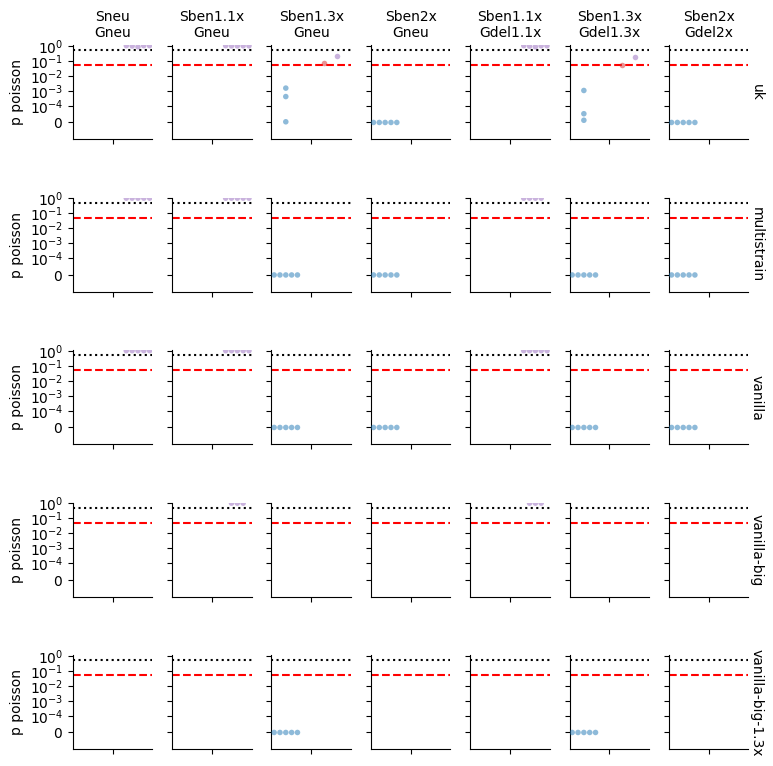

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.png


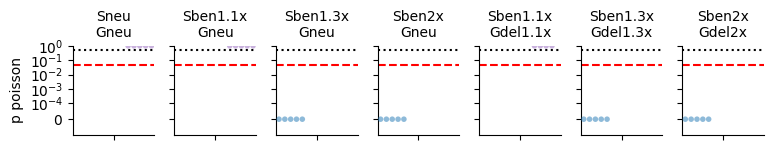

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.png


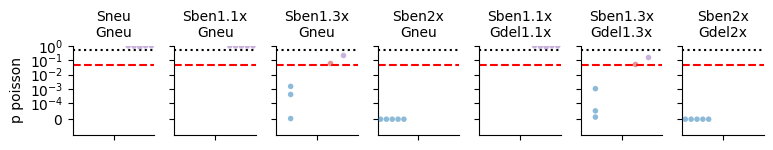

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.png


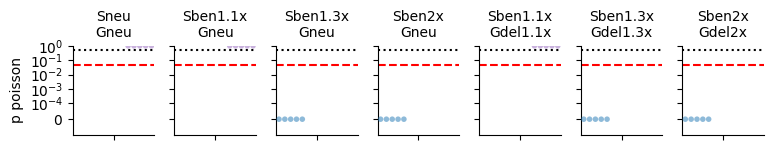

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.png


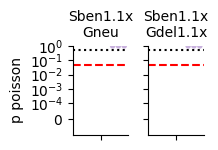

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.png


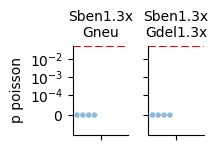

In [10]:
bins = [-np.inf, 0.005, 0.01, 0.05, 0.1, np.inf]
labels = ["<0.005", "<0.01", "<0.05", "<0.1", "ns"]

for y in ("p_poisson",):
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df
            .groupby(["trt_name","source_name"])["trt_n_downsample"]
            .transform("max")
        )
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        col="trt_name_",
        row="source_name",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.6,
        aspect=0.7,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    for source_name, group_df in data.groupby("source_name"):
        with tp.teed(
            sns.catplot,
            data=group_df,
            y=y,
            col="trt_name_",
            hue="sig",
            col_order=filter(
               set(group_df["trt_name_"]).__contains__,
               col_order,
            ),
            legend=False,
            kind="swarm",
            dodge=True,
            margin_titles=True,
            alpha=0.5,
            height=1.6,
            aspect=0.7,
            size=4,
            teeplot_outattrs={"source_name": source_name},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.set_titles(col_template="{col_name}", row_template="{row_name}")
            for ax in teed.axes.flat:
                ax.set_yscale("symlog", linthresh=0.0001)
                ax.set_ylim(-0.0001, None)
                ax.axhline(0.5, color="black", linestyle=":")
                ax.axhline(0.05, color="red", linestyle="--")
                ax.tick_params(axis="x", rotation=-60)
                ax.set_xlabel("")
                ax.set_ylabel(y.replace("_", " "))

            teed.tight_layout()


teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.png


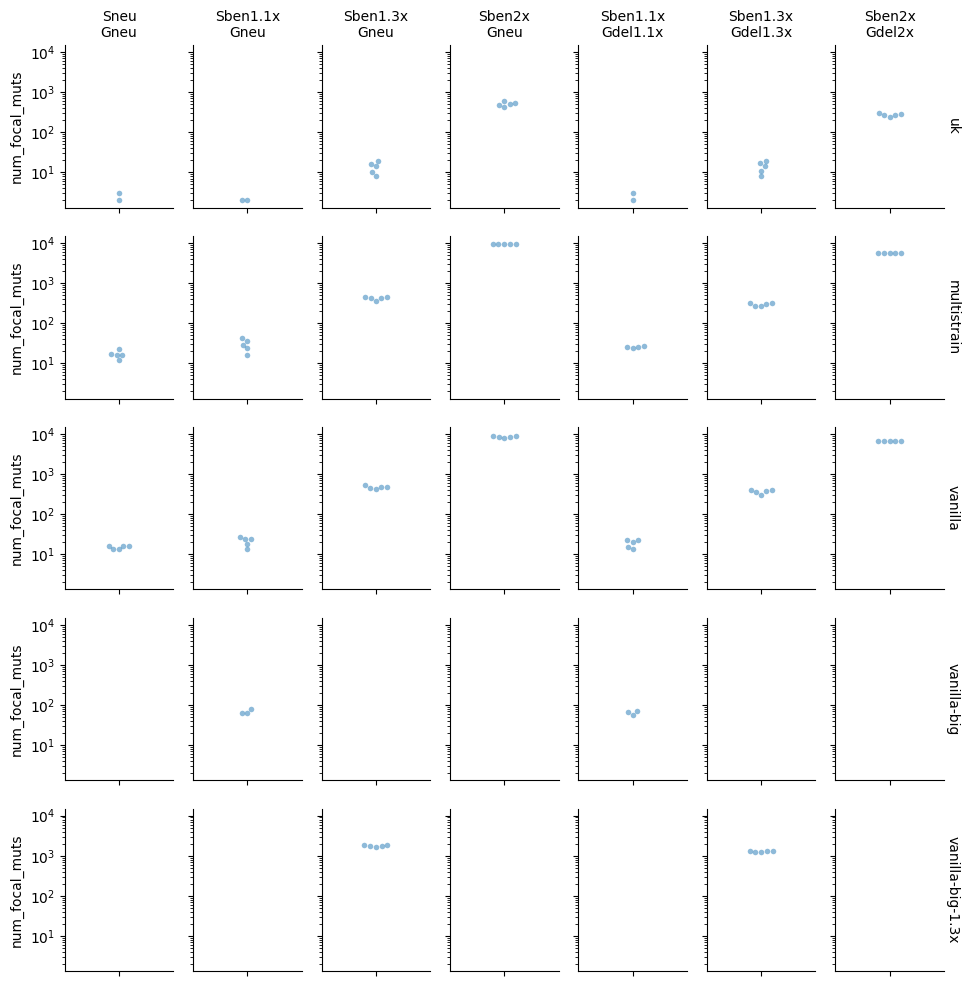

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.png


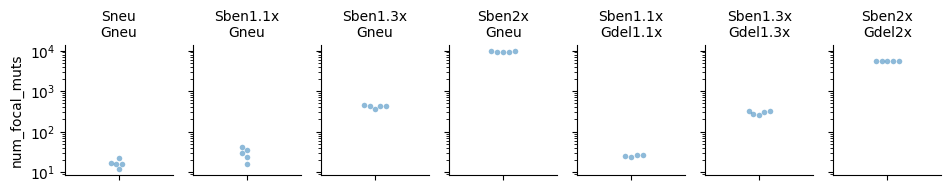

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.png


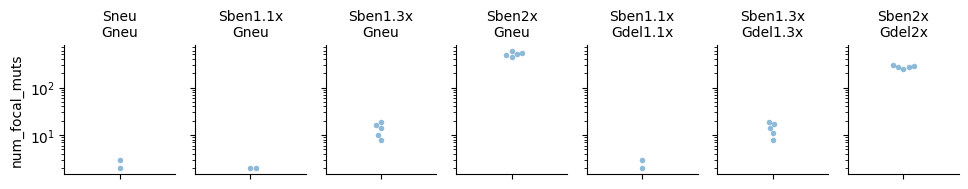

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.png


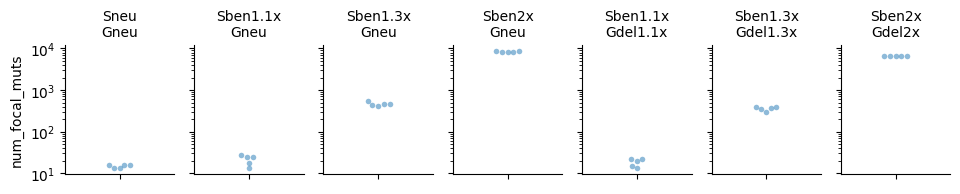

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.png


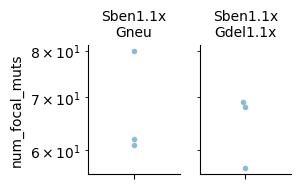

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.png


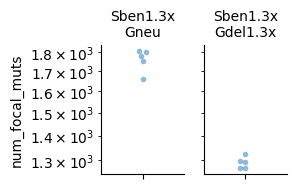

In [11]:
data = results_df[
    (results_df["trt_hsurf_bits"] == 0)
    & (
        results_df["trt_n_downsample"]
        == results_df
        .groupby(["trt_name","source_name"])["trt_n_downsample"]
        .transform("max")
    )
]

with tp.teed(
    sns.catplot,
    data=data,
    y="num_focal_muts",
    col="trt_name_",
    row="source_name",
    col_order=col_order,
    legend=False,
    kind="swarm",
    dodge=True,
    margin_titles=True,
    alpha=0.5,
    height=2,
    aspect=0.7,
    size=4,
    teeplot_subdir=teeplot_subdir,
) as teed:
    teed.set_titles(col_template="{col_name}", row_template="{row_name}")
    for ax in teed.axes.flat:
        ax.set_yscale("log")

        ax.set_xlabel("")

    teed.tight_layout()

for source_name, group_df in data.groupby("source_name"):
    with tp.teed(
        sns.catplot,
        data=group_df,
        y="num_focal_muts",
        col="trt_name_",
        col_order=filter(set(group_df["trt_name_"]).__contains__, col_order),
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=2,
        aspect=0.7,
        size=4,
        teeplot_outattrs={"source_name": source_name},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")

            ax.set_xlabel("")
